# 🌸 CosmeticWorld — Customer Lifecycle & RFM Analytics
---

## 1. Executive Summary

### Data-Driven VIP Segmentation

**CosmeticWorld** is a global beauty and body care retail chain with a dataset recording over **50,000 transactions**. Historically, the company relied on mass-marketing campaigns, which led to inefficient budget allocation and customer fatigue.

This project builds a data-driven growth strategy for the **"New Year Rejuvenation 2024"** campaign by combining:

* **Profit Optimization (Pareto / ABC Analysis)** — identify the "Vital Few" generating ~80% of total profits
* **Behavioral Segmentation (RFM Model)** — classify customers into 11 behavior segments based on Recency, Frequency, and Monetary value
* **Cross-referencing ABC × RFM** — resolve the 500-gift-set allocation problem with a data-backed shortlist
* **Retention & Cohort Analysis** — measure how customer buying habits evolve after the first purchase, and whether retention differs by segment or season

---

### Tech Stack & Tools

* **Language:** Python
* **Data Manipulation:** `pandas`, `numpy`
* **Data Visualization:** `seaborn`, `matplotlib`, `plotly.express`
* **Market Basket Mining:** `mlxtend` (Apriori & FP-Growth) — *planned for a later iteration*

---

### Key Objectives

1. **Profit Optimization (ABC Analysis):** Identify the "Vital Few" (Group A) generating ~80% of total profits.
2. **Behavioral Segmentation (RFM Model):** Classify the customer base into 11 distinct segments (*Champions, At Risk, Hibernating*, etc.).
3. **VIP Shortlist:** Cross-reference ABC Tier A with RFM Champions/Loyal to identify the top 500 gift-set recipients.
4. **Retention & Cohort Tracking:** Measure post-purchase retention by cohort, customer segment (*Consumer* vs. *Corporate*), and calendar seasonality.

## 2. Environment Setup

This section handles the initial configuration of the notebook: professional visualization standards and core library imports.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
from google.colab import drive
import matplotlib.ticker as mticker

# from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules  # for future Market Basket Analysis

# Configure professional visualization style
sns.set_theme(style="white")
plt.rcParams['axes.grid'] = False
plt.rcParams['figure.figsize'] = (12, 7)
warnings.filterwarnings('ignore')

# Connect to storage
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Data Acquisition

We load the raw **CosmeticWorld** datasets and perform an initial high-level inspection.

The project utilizes four primary relational tables:
- **Customer:** Demographic information.
- **EcomSales:** Granular transaction history.
- **Product:** Catalog categories and details.
- **Region:** Geographic location data.

In [ ]:
path = '/content/drive/MyDrive/Analytics/Dataset/CosmeticWorld/'

# Loading the four core CSV files
df_customer = pd.read_csv(path + 'Customer.csv')
df_sales = pd.read_csv(path + 'EcomSales.csv')
df_product = pd.read_csv(path + 'Product.csv')
df_region = pd.read_csv(path + 'Region.csv')

df_customer.head(2)


,CustomerID,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,EducationLevel,Occupation,HomeOwner
0,TH-211151,Jon,Huang,6/18/1962,M,M,jon24@hotmail.com,90000,Bachelors,Professional,Y
1,BD-116051,Eugene,Torres,6/16/1985,S,M,eugene10@hotmail.com,60000,Bachelors,Professional,N


In [ ]:
df_sales.head(2)


,RowID,OrderID,OrderDate,CustomerID,Segment,RegionCode,ProductCode,Quantity,Sales,Discount,Profit
0,25221,IN-2012-TH211151-41003,4/4/2020,TH-211151,Corporate,RRR0001,P000001,13,416,0.0,208.0
1,29464,ID-2013-BD116051-41518,9/1/2021,BD-116051,Consumer,R0002,PPP000002,4,20,0.0,10.0


In [ ]:
df_product.head(2)


,ProductCode,Product,Category,Subcategory
0,P000001,Soap & Glory Endless Glove Moisturizing Hand C...,Body care,"bath oils, bubbles and soaks"
1,P000002,Pantene Pro-V Truly Relaxed Hair Lightweight C...,Body care,"bath oils, bubbles and soaks"


In [ ]:
df_region.head(2)


,RegionCode,City,State,Country,Countrylatitude,Countrylongitude,Region,Market
0,R0001,Jalalabad,Nangarhar,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific
1,R0002,Herat,Hirat,Afghanistan,33.93911,67.709953,Southern Asia,Asia Pacific


## 4. Data Quality Assessment (Raw Tables)

We systematically examine the raw dataframes for missing values, structural anomalies, and duplicate records before any joins are performed.

In [ ]:
def assess_quality(df, name="Dataset", business_keys=None):
    """
    df : pandas.DataFrame — the input DataFrame to evaluate.
    business_keys : list of str, optional — column names forming the composite
        business key. Used to detect domain-level duplicates (since full-row
        duplicated() fails when unique technical IDs exist).
    """
    print(f"--- {name} Quality Assessment ---")
    print(f"Shape: {df.shape}")
    print(f"Full-row Duplicates: {df.duplicated().sum()}")

    if business_keys:
        bk_dup = df.duplicated(subset=business_keys).sum()
        print(f"Business-key Duplicates {business_keys}: {bk_dup}")
        if bk_dup > 0:
            print(">> NOTE: possible duplicates — review manually before dropping "
                  "(unlike Sales, these may be legitimate coincidences).")

    null_counts = df.isna().sum()
    total_nulls = null_counts.sum()
    print(f"Total Missing Values: {total_nulls}")
    if total_nulls > 0:
        print("\nMissing Values Detail:")
        print(null_counts[null_counts > 0])
    print("-" * 40)


In [ ]:
datasets = {
    "Sales": df_sales,
    "Customer": df_customer,
    "Product": df_product,
    "Region": df_region
}

# Business keys reflect real-world uniqueness, not just technical IDs:
# - ProductCode / RegionCode are technical IDs and are almost always unique
#   by design, so checking THEM adds little value.
# - What matters is whether two different technical IDs describe the SAME
#   real-world product / region (data entry duplication).
business_keys_map = {
    "Sales": ['OrderID', 'ProductCode'],
    "Customer": ['EmailAddress'],
    "Product": ['Product', 'Category', 'Subcategory'],
    "Region": ['City', 'State', 'Country']
}

for name, df in datasets.items():
    assess_quality(df, name, business_keys=business_keys_map[name])


--- Sales Quality Assessment ---
Shape: (51290, 11)
Full-row Duplicates: 0
Business-key Duplicates ['OrderID', 'ProductCode']: 102
>> NOTE: possible duplicates — review manually before dropping (unlike Sales, these may be legitimate coincidences).
Total Missing Values: 0
----------------------------------------
--- Customer Quality Assessment ---
Shape: (17415, 11)
Full-row Duplicates: 0
Business-key Duplicates ['EmailAddress']: 0
Total Missing Values: 124

Missing Values Detail:
Gender    124
dtype: int64
----------------------------------------
--- Product Quality Assessment ---
Shape: (28356, 4)
Full-row Duplicates: 0
Business-key Duplicates ['Product', 'Category', 'Subcategory']: 0
Total Missing Values: 0
----------------------------------------
--- Region Quality Assessment ---
Shape: (3828, 8)
Full-row Duplicates: 0
Business-key Duplicates ['City', 'State', 'Country']: 0
Total Missing Values: 0
----------------------------------------


**Data Quality Assessment Summary**

Overall the raw data is clean: Product and Region come in with zero duplicates and zero missing values. The one real issue is in `Sales`, which has duplicate records on `['OrderID', 'ProductCode']` — this needs fixing before any tables get joined, not after, or the duplication just propagates into `df_master`.

The only missing values anywhere are in `Customer.Gender` (124 rows), which gets imputed before the merge so nothing needs patching downstream. For `Product` and `Region`, any near-duplicate business keys are flagged for manual review rather than auto-dropped, since two different codes could legitimately describe the same real-world item.


## 5. Data Cleaning & Preprocessing

To build a robust analytical engine, the pipeline is split into three clearly separated stages — each with a single responsibility, so there is exactly **one** merge pipeline feeding all downstream analysis (ABC, RFM, and future Cohort/Market Basket work):

- **5a. Preprocessing:** dedup and aggregate `df_sales` at the Order+Product line-item level, and compute `Revenue` at the correct (pre-aggregation) grain.
- **5b. Merge:** join the cleaned, aggregated sales table with Product and Customer into a single `df_master`.
- **5c. Post-merge Normalization:** verify no phantom duplicates were introduced by the merge, and standardize text fields.

### 5a. Preprocessing (Dedup + Aggregate `df_sales`)

In [ ]:
print(f"Initial shape of df_sales: {df_sales.shape}")

df_sales['OrderDate'] = pd.to_datetime(df_sales['OrderDate'])

# Revenue must be computed at the LINE-ITEM level, before aggregation.
# Discount becomes a MEAN once we group by (OrderID, ProductCode) below, so
# Sales_total * (1 - mean_discount) would NOT equal the true summed revenue
# of the underlying rows. Computing Revenue here and then summing it avoids
# that distortion entirely.
df_sales['Revenue'] = df_sales['Sales'] * (1 - df_sales['Discount'])

# STEP 1: Remove fully duplicated rows (ETL errors) — no summing, just keep one record
cols_to_check = [c for c in df_sales.columns if c != 'RowID']
before_etl = len(df_sales)
df_sales = df_sales.drop_duplicates(subset=cols_to_check, keep='first')
print(f"Removed {before_etl - len(df_sales)} fully duplicated rows (ETL errors)")

# STEP 2: For the remaining rows, aggregate valid line items (Order + Product)
before_agg = len(df_sales)
df_sales_aggregated = df_sales.groupby(['OrderID', 'ProductCode'], as_index=False).agg(
    OrderDate=('OrderDate', 'first'),
    CustomerID=('CustomerID', 'first'),
    Segment=('Segment', 'first'),
    RegionCode=('RegionCode', 'first'),
    Quantity=('Quantity', 'sum'),
    Sales=('Sales', 'sum'),
    Revenue=('Revenue', 'sum'),
    Profit=('Profit', 'sum'),
    Discount=('Discount', 'mean')
)
print(f"Number of valid line-item rows aggregated: {before_agg - len(df_sales_aggregated)}")
print(f"Shape after preprocessing: {df_sales_aggregated.shape}")

# Sanity check: business-key duplicates should now be zero
assess_quality(df_sales_aggregated, "Sales (post-preprocessing)",
                business_keys=['OrderID', 'ProductCode'])


Initial shape of df_sales: (51290, 11)
Removed 9 fully duplicated rows (ETL errors)
Number of valid line-item rows aggregated: 93
Shape after preprocessing: (51188, 11)
--- Sales (post-preprocessing) Quality Assessment ---
Shape: (51188, 11)
Full-row Duplicates: 0
Business-key Duplicates ['OrderID', 'ProductCode']: 0
Total Missing Values: 0
----------------------------------------


### 5b. Merge (Sales + Product + Customer → `df_master`)

Note: `Gender` is imputed **before** the merge (not after) so the null values
never need to be patched a second time downstream.

In [ ]:
# Impute missing Gender BEFORE merging
df_customer['Gender'] = df_customer['Gender'].fillna('Others')
print(f"Missing values in Customer table: {df_customer.isna().sum().sum()}")

# Single merge pipeline — always uses the deduplicated, aggregated sales table
before = len(df_sales_aggregated)
df_master = pd.merge(df_sales_aggregated, df_product, on='ProductCode', how='inner')
print(f"Dropped {before - len(df_master)} rows due to unmatched ProductCode")

before = len(df_master)
df_master = pd.merge(df_master, df_customer, on='CustomerID', how='inner')
print(f"Dropped {before - len(df_master)} rows due to unmatched CustomerID")

print(f"Consolidated Dataset Shape: {df_master.shape}")
assess_quality(df_master, "Master Dataset after merge")


Missing values in Customer table: 0
Dropped 2 rows due to unmatched ProductCode
Dropped 0 rows due to unmatched CustomerID
Consolidated Dataset Shape: (51186, 24)
--- Master Dataset after merge Quality Assessment ---
Shape: (51186, 24)
Full-row Duplicates: 0
Total Missing Values: 0
----------------------------------------


### 5c. Post-merge Normalization

Since 5a already deduplicated and aggregated `df_sales` *before* the merge, this
step is a **verification / guard check** rather than a discovery step — it confirms
the merge with Product and Customer did not introduce phantom duplicates, and
standardizes text fields for downstream Market Basket Analysis.

In [ ]:
# Integrity guard: confirm no duplicate rows survived the merge
before_dedup = len(df_master)
df_master.drop_duplicates(inplace=True)
print(f"Removed {before_dedup - len(df_master)} residual duplicate rows after merge")

# Text normalization — prevents downstream MBA algorithms from treating
# "Hand Creams" and "hand creams " as separate entities
df_master['Subcategory'] = df_master['Subcategory'].str.strip().str.lower()
df_master['Product'] = df_master['Product'].str.strip()

df_master['OrderDate'] = pd.to_datetime(df_master['OrderDate'])

assess_quality(df_master, "Cleaned Master Dataset")


Removed 0 residual duplicate rows after merge
--- Cleaned Master Dataset Quality Assessment ---
Shape: (51186, 24)
Full-row Duplicates: 0
Total Missing Values: 0
----------------------------------------


## 6. Visualizing Distribution: Profit Contribution (ABC Analysis)

We analyze the structural composition of CosmeticWorld's profit distribution by applying the **Pareto Principle (80/20 Rule)**, segmenting the customer base into three tiers (A, B, C) to support the "New Year Rejuvenation 2024" campaign strategy.

**Key Objectives & Context:**
- **Pareto / ABC Classification:** Group customers into Tier A (Top ~80% cumulative profit), Tier B (Next ~15%), Tier C (Remaining ~5%).
- **Budget Constraint Mapping:** The Marketing Director has authorized **500 premium gift sets** for top-tier clientele.
- **Targeting Optimization:** Being in Tier A alone is not sufficient to fit the 500-unit cap — Section 8 cross-references ABC with RFM to resolve this.

In [ ]:
customer_profit = df_master.groupby('CustomerID').agg({'Profit': 'sum'}).reset_index()
customer_profit.rename(columns={'Profit': 'TotalProfit'}, inplace=True)

customer_profit = customer_profit.sort_values(by='TotalProfit', ascending=False).reset_index(drop=True)

customer_profit['CumulativeProfit'] = customer_profit['TotalProfit'].cumsum()
customer_profit['CumulativeProfitPct'] = customer_profit['CumulativeProfit'] / customer_profit['TotalProfit'].sum()

customer_profit.head()


,CustomerID,TotalProfit,CumulativeProfit,CumulativeProfitPct
0,AR-1082564,2625.3,2625.3,0.002465
1,LS-172001402,2429.4,5054.7,0.004746
2,MY-1829527,2165.0,7219.7,0.006778
3,ML-73952,2156.0,9375.7,0.008803
4,YS-2188093,2095.9,11471.6,0.010770


**Known Limitation:** The cumulative profit curve can exceed 100% due to the
presence of negative-margin transactions (deep discounting + structurally
low-margin categories). Rigorously fixing this would mean separating negative-profit
transactions from the Pareto denominator — out of scope for this iteration and
flagged here as future work. Customers whose cumulative contribution pushes past
100% (a `NaN` from `pd.cut`) are mapped to Tier C, since they represent the
bottom / net-negative contributors regardless.

In [ ]:
bins = [0, 0.8, 0.95, 1.1]
labels = ['A', 'B', 'C']

customer_profit['ABC_Rank'] = pd.cut(customer_profit['CumulativeProfitPct'],
                                      bins=bins, labels=labels, include_lowest=True)

customer_profit['ABC_Rank'] = customer_profit['ABC_Rank'].fillna('C')

print(customer_profit['ABC_Rank'].value_counts())


ABC_Rank
C    13944
A     2254
B     1217
Name: count, dtype: int64


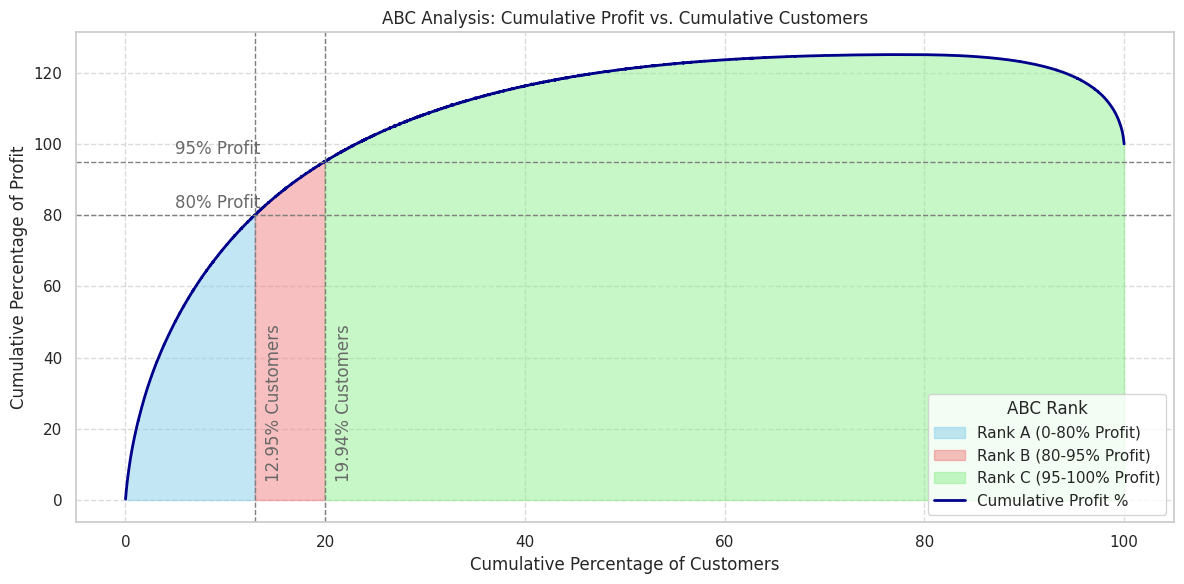

In [ ]:
# Make a copy to avoid modifying the original DataFrame directly
customer_profit_plot = customer_profit.copy()

# Ensure sorted by TotalProfit descending for correct cumulative calculation
customer_profit_plot = customer_profit_plot.sort_values(by='TotalProfit', ascending=False).reset_index(drop=True)

# Calculate cumulative customer percentage for the X-axis
customer_profit_plot['customer_percentage'] = (customer_profit_plot.index + 1) / len(customer_profit_plot) * 100

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Find the customer_percentage points where CumulativeProfitPct crosses the ABC thresholds
idx_profit_80 = (customer_profit_plot['CumulativeProfitPct'] > 0.8).idxmax()
cust_pct_at_80_profit = customer_profit_plot.loc[idx_profit_80, 'customer_percentage']

idx_profit_95 = (customer_profit_plot['CumulativeProfitPct'] > 0.95).idxmax()
cust_pct_at_95_profit = customer_profit_plot.loc[idx_profit_95, 'customer_percentage']

# Area for A: from x=0 to cust_pct_at_80_profit
x_A = customer_profit_plot[customer_profit_plot['customer_percentage'] <= cust_pct_at_80_profit]['customer_percentage']
y_A = customer_profit_plot[customer_profit_plot['customer_percentage'] <= cust_pct_at_80_profit]['CumulativeProfitPct'] * 100
plt.fill_between(x_A, 0, y_A, color='skyblue', alpha=0.5, label='Rank A (0-80% Profit)')

# Area for B: from cust_pct_at_80_profit to cust_pct_at_95_profit
x_B = customer_profit_plot[(customer_profit_plot['customer_percentage'] > cust_pct_at_80_profit) &
                            (customer_profit_plot['customer_percentage'] <= cust_pct_at_95_profit)]['customer_percentage']
y_B = customer_profit_plot[(customer_profit_plot['customer_percentage'] > cust_pct_at_80_profit) &
                            (customer_profit_plot['customer_percentage'] <= cust_pct_at_95_profit)]['CumulativeProfitPct'] * 100
plt.fill_between(x_B, 0, y_B, color='lightcoral', alpha=0.5, label='Rank B (80-95% Profit)')

# Area for C: from cust_pct_at_95_profit to 100% customer percentage
x_C = customer_profit_plot[customer_profit_plot['customer_percentage'] > cust_pct_at_95_profit]['customer_percentage']
y_C = customer_profit_plot[customer_profit_plot['customer_percentage'] > cust_pct_at_95_profit]['CumulativeProfitPct'] * 100
plt.fill_between(x_C, 0, y_C, color='lightgreen', alpha=0.5, label='Rank C (95-100% Profit)')

# Main cumulative profit curve on top for visibility
plt.plot(customer_profit_plot['customer_percentage'], customer_profit_plot['CumulativeProfitPct'] * 100,
         color='darkblue', linewidth=2, label='Cumulative Profit %')

# Reference lines for 80% and 95% cumulative profit
plt.axvline(x=cust_pct_at_80_profit, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=80, color='gray', linestyle='--', linewidth=1)
plt.text(cust_pct_at_80_profit + 1, 5, f'{cust_pct_at_80_profit:.2f}% Customers', rotation=90, va='bottom', ha='left', color='dimgray')
plt.text(5, 80 + 1, '80% Profit', va='bottom', ha='left', color='dimgray')

plt.axvline(x=cust_pct_at_95_profit, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=95, color='gray', linestyle='--', linewidth=1)
plt.text(cust_pct_at_95_profit + 1, 5, f'{cust_pct_at_95_profit:.2f}% Customers', rotation=90, va='bottom', ha='left', color='dimgray')
plt.text(5, 95 + 1, '95% Profit', va='bottom', ha='left', color='dimgray')

plt.xlabel('Cumulative Percentage of Customers')
plt.ylabel('Cumulative Percentage of Profit')
plt.title('ABC Analysis: Cumulative Profit vs. Cumulative Customers')
plt.legend(title='ABC Rank', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Key Insights: Profit Optimization & Gift Allocation**

The Pareto pattern holds here — a small slice of customers accounts for roughly 80% of total profit, confirming a highly concentrated revenue base. The catch is that this top tier (Tier A) is much larger than the 500 gift sets budgeted for the campaign, so profitability alone isn't a fine enough filter. Section 8 narrows this down further by cross-referencing Tier A with RFM (Champions/Loyal) to land on a shortlist that actually fits the budget.

## 7. RFM Analysis

**RFM** is a method used to group customers based on 3 shopping behaviors:

| Metric | Meaning | How to calculate |
|---|---|---|
| R — Recency | How recently did they buy? (days) | Days since the last purchase → the **smaller**, the better |
| F — Frequency | How many times did they buy? | Total number of orders → the **bigger**, the better |
| M — Monetary | How much money did they spend? | Total revenue → the **bigger**, the better |

**Snapshot date:** The latest order date in the whole dataset is used as the baseline to calculate Recency.

Unlike the original exploratory notebook, this section reuses **`df_master`** — already deduplicated and merged in Section 5 — instead of re-deriving a fresh `df` from raw `df_sales`. This avoids redoing (and under-performing) the cleaning work, and keeps a single source of truth for both ABC and RFM.

### 7a. Aggregate RFM Metrics per Customer

In [ ]:
snapshot_date = df_master['OrderDate'].max()

# frequency uses nunique(OrderID), not row count, since df_master is at the
# line-item grain (one row per Order+Product) — counting rows would inflate
# frequency for orders containing multiple products.
df_rfm = df_master.groupby('CustomerID', as_index=False).agg(
    last_order_date=('OrderDate', 'max'),
    frequency=('OrderID', 'nunique'),
    monetary=('Revenue', 'sum')
)
df_rfm['recency'] = (snapshot_date - df_rfm['last_order_date']).dt.days
df_rfm = df_rfm[['CustomerID', 'recency', 'frequency', 'monetary']]

print(f"Snapshot date used: {snapshot_date.date()}")
df_rfm.head()


Snapshot date used: 2023-12-31


,CustomerID,recency,frequency,monetary
0,AA-10315102,358,2,506.8
1,AA-10315120,959,1,63.0
2,AA-10315139,149,4,596.6
3,AA-103151402,184,2,195.8
4,AA-103151404,818,2,213.6


### 7b. RFM Scoring

Each metric (R, F, M) is divided into **5 levels** from 1 to 5, where **5 is the best score**.

**Note about score directions:**
- **R:** smaller Recency → higher score → we use `qcut` with reversed labels `[5,4,3,2,1]`
- **F, M:** bigger values → higher score → normal labels `[1,2,3,4,5]`

**Why custom bins for Frequency:** Frequency is heavily right-skewed (most customers buy only 1-2 times), so `pd.qcut` cannot split it evenly — it typically collapses into far fewer than 5 groups and forces a majority of customers into a single bucket, which is too generic for targeted marketing. Custom bins fix this by keeping 5 meaningful, well-balanced groups.

In [ ]:
print(df_rfm['frequency'].value_counts().sort_index())


frequency
1    11979
2     3467
3     1311
4      457
5      158
6       29
7       12
8        1
9        1
Name: count, dtype: int64


In [ ]:
# Custom bins based on the observed distribution
custom_bins = [0, 1, 2, 4, 7, df_rfm['frequency'].max()]
custom_labels = [1, 2, 3, 4, 5]

df_rfm['R_score'] = pd.qcut(df_rfm['recency'], 5, duplicates='drop',
                             labels=[5, 4, 3, 2, 1]).astype(int)
df_rfm['F_score'] = pd.cut(df_rfm['frequency'], bins=custom_bins,
                            labels=custom_labels, include_lowest=True).astype(int)
df_rfm['M_score'] = pd.qcut(df_rfm['monetary'], 5, duplicates='drop',
                             labels=[1, 2, 3, 4, 5]).astype(int)

df_rfm.head()


,CustomerID,recency,frequency,monetary,R_score,F_score,M_score
0,AA-10315102,358,2,506.8,3,2,5
1,AA-10315120,959,1,63.0,1,1,2
2,AA-10315139,149,4,596.6,4,3,5
3,AA-103151402,184,2,195.8,4,2,3
4,AA-103151404,818,2,213.6,2,2,4


### 7c. Create the Final RFM Score

Each customer gets a **3-digit score code**: `RFM_score = 100*R + 10*F + M`.

Example: R=5, F=4, M=3 → RFM_score = **543**.

In [ ]:
df_rfm['RFM_score'] = 100*df_rfm['R_score'] + 10*df_rfm['F_score'] + df_rfm['M_score']
df_rfm.head()


,CustomerID,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,AA-10315102,358,2,506.8,3,2,5,325
1,AA-10315120,959,1,63.0,1,1,2,112
2,AA-10315139,149,4,596.6,4,3,5,435
3,AA-103151402,184,2,195.8,4,2,3,423
4,AA-103151404,818,2,213.6,2,2,4,224


### 7d. Customer Segmentation (RFM Segmentation)

Each customer is placed into one of **11 behavior segments** using the RFM matrix below.
This version has been fully validated: **0 duplicate RFM_score values across segments**
and **complete coverage of all 125 possible R×F×M combinations** (no customer falls into
an undefined "Other" bucket) — confirmed programmatically before being adopted here.

In [ ]:
segment_map = {
    'Champions': [555, 554, 544, 545, 454, 455, 445],
    'Loyal': [543, 444, 435, 355, 354, 345, 344, 335],
    'Potential Loyalist': [553, 551, 552, 541, 542, 533, 532, 531, 452, 451, 442, 441,
                           431, 453, 433, 432, 423, 353, 352, 351, 342, 341, 333, 323],
    'Promising': [525, 524, 523, 522, 521, 515, 514, 513, 425, 424, 413, 414, 415, 315, 314, 313],
    'New Customers': [512, 511, 422, 421, 412, 411, 311],
    'Need Attention': [535, 534, 443, 434, 343, 334, 325, 324],
    'About To Sleep': [331, 321, 312, 221, 213, 231, 241, 251],
    'At Risk': [255, 254, 245, 244, 253, 252, 243, 242, 235, 234, 225, 224, 153, 152,
                145, 143, 142, 135, 134, 133, 125, 124],
    'Cannot Lose Them': [155, 154, 144, 214, 215, 115, 114, 113],
    'Hibernating customers': [332, 322, 233, 232, 223, 222, 132, 123, 122, 212, 211],
    'Lost customers': [111, 112, 121, 131, 141, 151],
}

df_rfm['RFM_Segment'] = 'Other'  # default label for rows not matching any segment
for segment, scores in segment_map.items():
    df_rfm.loc[df_rfm['RFM_score'].isin(scores), 'RFM_Segment'] = segment

# Verify coverage: should be 0 if the mapping is correct and complete
print(f"Customers falling into 'Other': {(df_rfm['RFM_Segment'] == 'Other').sum()}")
print(df_rfm['RFM_Segment'].value_counts())


Customers falling into 'Other': 0
RFM_Segment
Promising                4321
New Customers            2776
Cannot Lose Them         2295
Hibernating customers    1919
Lost customers           1674
Need Attention           1320
About To Sleep           1170
Potential Loyalist        689
At Risk                   623
Loyal                     473
Champions                 155
Name: count, dtype: int64


### 7e. RFM Segment Interpretation

Before reviewing the segmentation results, below is the business interpretation for each group — helping guide marketing strategies based not only on numerical RFM scores, but also on understanding the **actual behavior** behind them.

| Segment | R (Recency) | F (Frequency) | M (Monetary) | Meaning & Behavior | Strategic Suggestions |
|---|---|---|---|---|---|
| **Champions** | High | High | High | Bought recently, buy frequently, spend the most — the most valuable customer segment | Prioritize for VIP treatment, early access to new products, highest loyalty rewards |
| **Loyal** | Mid-High | High | Mid-High | Buy regularly over time, strong brand affinity | Membership programs, upsell higher-tier products |
| **Potential Loyalist** | High | Medium | Medium | Recent customers who have bought a few times, showing potential to become Loyal | Encourage 2nd and 3rd purchases with personalized offers |
| **Promising** | High | Low | Mid-Low | Bought recently but insufficient data to fully evaluate; positive signals | Nurture with onboarding emails, introduce related products |
| **New Customers** | High | Very Low | Low | Just made their first purchase, no prior history | Welcome series, product guides, collect initial feedback |
| **Need Attention** | Medium | Mid-High | Mid-High | Former good customers whose purchase frequency is slowing down | Re-engage with limited-time offers before they churn |
| **About To Sleep** | Mid-Low | Low | Low | Both Recency and Frequency are declining — early signs of brand churn | "We miss you" email campaigns, reactivation discounts |
| **At Risk** | Low | Mid-High | Mid-High | Spent significantly in the past but haven't returned in a long time — high churn risk | Personalized win-back campaigns, exit surveys to understand reasons |
| **Cannot Lose Them** | Low | High | High | Used to be top-value customers but inactive for a long time — highest potential revenue loss | Direct personal contact, exclusive retention offers, highest priority among at-risk segments |
| **Hibernating customers** | Low | Low | Low | Made very few purchases and inactive for a long time, but not fully lost | Low-cost reactivation campaigns (e.g., automated mass emails) |
| **Lost customers** | Very Low | Very Low | Very Low | Recency, Frequency, and Monetary are all at absolute minimums — essentially churned | Lowest budget priority; exclude from expensive marketing campaigns |

**Note linking to Section 9:** The **Champions** and **Loyal** segments form the baseline for the VIP shortlist of 500 gift sets (Section 9). These customers combine high profitability (ABC Tier A) with active engagement (high RFM) — preventing budget waste on sending gifts to customers who historically spent a lot but have already churned (e.g., Cannot Lose Them or At Risk).

## 8. Segmentation Results & Revenue Contribution

In [ ]:
df_rfm_summary = df_rfm.groupby('RFM_Segment', as_index=False).agg(
    total_customers=('CustomerID', 'nunique'),
    total_revenue=('monetary', 'sum')
)
df_rfm_summary['pct_customers'] = df_rfm_summary['total_customers'] / df_rfm_summary['total_customers'].sum()
df_rfm_summary['pct_revenue'] = df_rfm_summary['total_revenue'] / df_rfm_summary['total_revenue'].sum()

df_rfm_summary.sort_values('total_revenue', ascending=False)


,RFM_Segment,total_customers,total_revenue,pct_customers,pct_revenue
10,Promising,4321,1879454.266,0.248119,0.337769
2,Cannot Lose Them,2295,1072897.794,0.131783,0.192818
7,Need Attention,1320,892967.702,0.075797,0.160481
6,Loyal,473,574409.694,0.027160,0.103231
1,At Risk,623,431377.272,0.035774,0.077526
3,Champions,155,223020.440,0.008900,0.040080
0,About To Sleep,1170,116470.048,0.067183,0.020932
4,Hibernating customers,1919,107894.070,0.110192,0.019390
8,New Customers,2776,101044.722,0.159403,0.018159
9,Potential Loyalist,689,97243.966,0.039564,0.017476


In [ ]:
treemap_input = df_rfm.groupby('RFM_Segment', as_index=False).agg(
    count_cus=('CustomerID', 'nunique'),
    total_rev=('monetary', 'sum')
)

# Treemap: Customer Count
fig_count = px.treemap(treemap_input, path=['RFM_Segment'], values='count_cus',
                        title='RFM Segments - Customer Count Treemap')
fig_count.show()

# Treemap: Revenue Contribution
fig_rev = px.treemap(treemap_input, path=['RFM_Segment'], values='total_rev',
                      title='RFM Segments - Total Revenue Treemap')
fig_rev.show()


## 9. Cross-Referencing ABC × RFM: Solving the 500-Gift-Set Allocation

Section 6 showed that ABC Tier A alone contains far more customers than the
500-gift-set budget allows. Here we combine Tier A (profit concentration) with
RFM segment (behavioral loyalty) to shortlist the highest-impact VIPs — customers
who are both **high-profit** and **currently active/loyal**, rather than high-profit
customers who may already be churning.

In [ ]:
abc_rfm = pd.merge(customer_profit[['CustomerID', 'TotalProfit', 'ABC_Rank']],
                    df_rfm[['CustomerID', 'recency', 'frequency', 'monetary',
                             'RFM_score', 'RFM_Segment']],
                    on='CustomerID', how='inner')

# Cross-tab: how ABC tiers distribute across RFM segments
cross_tab = pd.crosstab(abc_rfm['ABC_Rank'], abc_rfm['RFM_Segment'])
cross_tab


RFM_Segment,About To Sleep,At Risk,Cannot Lose Them,Champions,Hibernating customers,Lost customers,Loyal,Need Attention,New Customers,Potential Loyalist,Promising
ABC_Rank,,,,,,,,,,,
A,0,216,511,92,0,0,284,410,0,0,741
B,0,119,339,19,0,0,72,220,0,0,448
C,1170,288,1445,44,1919,1674,117,690,2776,689,3132


In [ ]:
# VIP shortlist: Tier A customers who are also currently loyal/active
# (Champions or Loyal), ranked by profit — capped at the 500-gift-set budget
vip_shortlist = abc_rfm[
    (abc_rfm['ABC_Rank'] == 'A') &
    (abc_rfm['RFM_Segment'].isin(['Champions', 'Loyal']))
].sort_values('TotalProfit', ascending=False)

print(f"Tier A customers total: {(abc_rfm['ABC_Rank'] == 'A').sum()}")
print(f"Tier A + Champions/Loyal: {len(vip_shortlist)}")

vip_gift_list = vip_shortlist.head(500)
print(f"Initial VIP gift-set shortlist: {len(vip_gift_list)} customers")

vip_gift_list

Tier A customers total: 2254
Tier A + Champions/Loyal: 376
Initial VIP gift-set shortlist: 376 customers


,CustomerID,TotalProfit,ABC_Rank,recency,frequency,monetary,RFM_score,RFM_Segment
6,ON-1871545,2071.950,A,426,5,4645.050,345,Loyal
12,MF-1825027,1790.400,A,210,3,4650.000,435,Loyal
13,BS-1136518,1778.742,A,138,5,5335.542,445,Champions
16,KH-1669045,1741.500,A,176,4,3929.400,435,Loyal
17,LA-167801406,1738.100,A,401,3,4274.000,335,Loyal
...,...,...,...,...,...,...,...,...
2218,CC-222023,165.800,A,485,5,396.000,344,Loyal
2223,MC-1763582,165.450,A,282,5,2984.600,445,Champions
2232,AH-1012082,165.078,A,502,5,649.528,345,Loyal
2242,TB-2152059,164.090,A,135,4,723.690,435,Loyal


In [ ]:
remaining_gifts_needed = 500 - len(vip_gift_list)

# Get CustomerIDs already in the VIP shortlist to exclude them
existing_vip_customers = vip_gift_list['CustomerID'].tolist()

# Identify Tier A customers not already in the VIP shortlist
additional_candidates = abc_rfm[
    (abc_rfm['ABC_Rank'] == 'A') &
    (~abc_rfm['CustomerID'].isin(existing_vip_customers)) # Exclude already selected VIPs
].sort_values('TotalProfit', ascending=False)

# Select the required number of additional customers
additional_vip_customers = additional_candidates.head(remaining_gifts_needed)

# Combine with the existing vip_gift_list
final_vip_gift_list = pd.concat([vip_gift_list, additional_vip_customers])

print(f"Initial VIP gift-set shortlist: {len(vip_gift_list)} customers")
print(f"Additional Tier A customers added: {len(additional_vip_customers)}")
print(f"Final VIP gift-set shortlist: {len(final_vip_gift_list)} customers")

vip_gift_list = final_vip_gift_list.sort_values('TotalProfit', ascending=False).reset_index()

vip_gift_list

Initial VIP gift-set shortlist: 500 customers
Additional Tier A customers added: 0
Final VIP gift-set shortlist: 500 customers


,index,CustomerID,TotalProfit,ABC_Rank,recency,frequency,monetary,RFM_score,RFM_Segment
0,0,AR-1082564,2625.300,A,205,2,5938.000,425,Promising
1,1,LS-172001402,2429.400,A,152,2,6840.000,425,Promising
2,2,MY-1829527,2165.000,A,1055,2,5265.000,125,At Risk
3,3,ML-73952,2156.000,A,981,1,4522.000,115,Cannot Lose Them
4,4,YS-2188093,2095.900,A,803,2,4443.000,225,At Risk
...,...,...,...,...,...,...,...,...,...
495,2218,CC-222023,165.800,A,485,5,396.000,344,Loyal
496,2223,MC-1763582,165.450,A,282,5,2984.600,445,Champions
497,2232,AH-1012082,165.078,A,502,5,649.528,345,Loyal
498,2242,TB-2152059,164.090,A,135,4,723.690,435,Loyal


> **Observations & Insights:**
>
> * **Shortfall in Core Segment:** The top-priority group, **Tier A ∩ (Champions ∪ Loyal)**, yields only **376 customers**, falling short of the 500-customer target.
>
> * **Backfill Strategy:** To fill the remaining **124 slots**, the list is backfilled by selecting top performers from the rest of **Tier A** ranked strictly by total profit (**`TotalProfit`**), regardless of their RFM segment.
>
> * **Note on Segmentation:** The originally intended backup group (*Potential Loyalist*) contains zero customers in Tier A. Consequently, the 124 backfilled slots are naturally absorbed by other segments (such as *Promising* or *Cannot Lose Them*). Because selection is driven purely by `TotalProfit`, this supplemental cohort prioritizes historical profit value over current engagement levels.

## 10. Retention & Cohort Analysis

After we know **who** the VIP customers are (from ABC + RFM), this section helps us answer a simple question: *When customers buy for the first time, how likely are they to come back and buy again?*

**Cohort Analysis** puts customers into groups based on the month of their **first purchase** (called a "cohort"). Then, we track their shopping activity in the following months using `month_after`. This number shows how many months have passed since *their own* first order (it is not a real calendar month).

> **Important Note:**
> The main goal of Cohort Analysis here is to check **how stable customer buying habits are over time**, **not** to measure monthly revenue. Because `month_after = 0` happens at different times for each customer group, this heatmap does not show sales by calendar months.
>
> **How to check for holiday/seasonal effects:**
> If all customer groups buy more in the same real month (for example, everyone buys more in December), this spike will show up as a **diagonal line** across the heatmap, not a single column. Section 10e below will show another chart arranged by calendar months to make this easier to see.

In this section, we use **`df_master`** (which was cleaned and merged in Section 5). We do not reload or filter the raw data again. This keeps our data consistent across ABC, RFM, and Cohort analyses.

### 10a. Identify First Purchase Month & Cohort Index

We only need `CustomerID` and `OrderDate` to build cohorts. Since `df_master`
is at the line-item grain (one row per Order+Product), a customer can have
multiple rows on the same date — we drop duplicates on `['CustomerID','OrderDate']`
so each customer is counted once per calendar day.

In [ ]:
df_cohort_base = df_master[['CustomerID', 'OrderDate']].drop_duplicates()

# First purchase date & month per customer
df_first_time = df_cohort_base.groupby('CustomerID', as_index=False)['OrderDate'].min()
df_first_time.columns = ['CustomerID', 'FirstPurchaseDate']
df_first_time['FirstMonth'] = df_first_time['FirstPurchaseDate'].dt.to_period('M')

# Merge back and compute months since first purchase
df_pre_cohort = df_cohort_base.merge(df_first_time, on='CustomerID', how='inner')
df_pre_cohort['month_after'] = (
    (df_pre_cohort['OrderDate'].dt.year - df_pre_cohort['FirstPurchaseDate'].dt.year) * 12 +
    (df_pre_cohort['OrderDate'].dt.month - df_pre_cohort['FirstPurchaseDate'].dt.month)
)

df_pre_cohort.head()


,CustomerID,OrderDate,FirstPurchaseDate,FirstMonth,month_after
0,PO-8865138,2020-10-02,2020-10-02,2020-10,0
1,EB-4110138,2022-10-14,2022-10-14,2022-10,0
2,MY-7380138,2022-12-31,2022-12-31,2022-12,0
3,GH-4665138,2023-12-13,2023-12-13,2023-12,0
4,JD-5790138,2023-03-07,2023-03-07,2023-03,0


### 10b. Build the Cohort Table (Customer Counts)

We pivot so each **row** is a cohort (first purchase month) and each **column**
is the cohort index (`month_after`). We focus on cohorts starting in **2022**,
since they have enough months of history to observe.

**Fix applied:** the source notebook used `aggfunc='count'`, which counts
**rows**, not unique customers — a customer with two distinct order dates in
the same `month_after` bucket would be counted twice, inflating both cohort
size and later-month counts. We use `aggfunc='nunique'` on `CustomerID` instead,
consistent with how Sections 10f/10g compute retention.

In [ ]:
df_cohort_table = df_pre_cohort.pivot_table(
    index='FirstMonth', columns='month_after',
    values='CustomerID', aggfunc='nunique'
)
df_cohort_table = df_cohort_table[df_cohort_table.index.year == 2022]
df_cohort_table = df_cohort_table.dropna(axis=1, how='all')

df_cohort_table


month_after,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
FirstMonth,,,,,,,,,,,,,,,,,,,,,
2022-01,252.0,1.0,1.0,4.0,4.0,3.0,4.0,6.0,7.0,4.0,...,4.0,1.0,3.0,8.0,5.0,8.0,9.0,6.0,2.0,8.0
2022-02,214.0,4.0,2.0,5.0,1.0,2.0,7.0,5.0,5.0,5.0,...,2.0,6.0,1.0,3.0,8.0,7.0,5.0,9.0,5.0,NaN
2022-03,290.0,2.0,5.0,4.0,4.0,9.0,10.0,3.0,7.0,13.0,...,7.0,14.0,2.0,8.0,13.0,3.0,14.0,10.0,NaN,NaN
2022-04,258.0,1.0,5.0,2.0,3.0,5.0,3.0,6.0,7.0,1.0,...,4.0,5.0,4.0,6.0,4.0,13.0,7.0,NaN,NaN,NaN
2022-05,352.0,7.0,7.0,10.0,8.0,5.0,7.0,13.0,5.0,3.0,...,3.0,10.0,7.0,8.0,11.0,15.0,NaN,NaN,NaN,NaN
2022-06,517.0,6.0,17.0,13.0,6.0,6.0,17.0,10.0,6.0,8.0,...,11.0,17.0,13.0,15.0,11.0,NaN,NaN,NaN,NaN,NaN
2022-07,292.0,8.0,8.0,4.0,6.0,10.0,3.0,4.0,6.0,2.0,...,6.0,9.0,11.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
2022-08,442.0,13.0,9.0,6.0,9.0,5.0,6.0,10.0,6.0,10.0,...,11.0,12.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,518.0,9.0,15.0,16.0,9.0,7.0,10.0,6.0,18.0,8.0,...,16.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


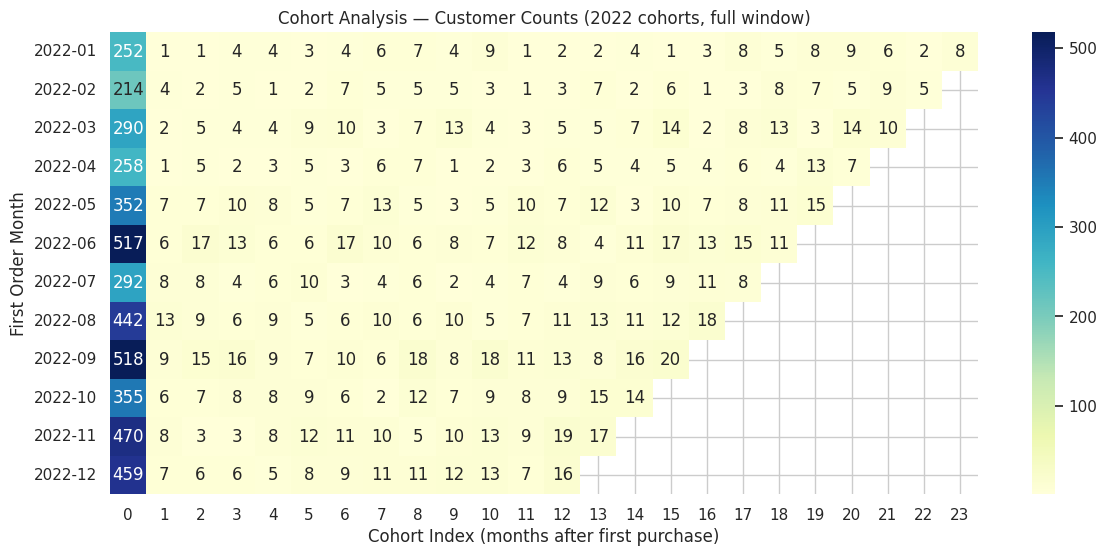

In [ ]:
plt.figure(figsize=(14, 6))
sns.heatmap(data=df_cohort_table, annot=True, cmap='YlGnBu', fmt='g')
plt.xlabel('Cohort Index (months after first purchase)')
plt.ylabel('First Order Month')
plt.title('Cohort Analysis — Customer Counts (2022 cohorts, full window)')
plt.show()


**Why later columns (large `month_after` values) usually have noise:**

In Month 1, Month 2, Month 3, and later, the number of customers who **actually come back to buy** in each month is already very small. Because this number is small, a **change of just 1–2 customers** between months (for example, one more customer buys, or one customer stops buying) is enough to make the retention rate **go up or down very fast**. This does not show real customer behavior, but just noise from a small sample size.

For example, if Month 10 has only 8 returning customers, adding or losing 1 customer changes the retention rate by about 12%. This is why columns far from Month 1 change a lot on the heatmap, and why you should only look at the M1–M12 range (see 10d) instead of trying to find rules in later months.

In [ ]:
# Evidence of shrinking cohort size in later months (drives the M12 cutoff below)
avg_customers_by_month_after = df_cohort_table.mean(axis=0, skipna=True)
print("Average remaining customers per cohort, by month_after:")
print(avg_customers_by_month_after.round(1))


Average remaining customers per cohort, by month_after:
month_after
0     368.2
1       6.0
2       7.1
3       6.8
4       5.9
5       6.8
6       7.8
7       7.2
8       7.9
9       6.9
10      7.7
11      6.6
12      8.6
13      8.8
14      7.8
15     10.4
16      7.4
17      8.0
18      8.7
19      9.2
20      8.8
21      8.3
22      3.5
23      8.0
dtype: float64


### 10c. Convert to Retention Rate (%)

$$\text{Retention Rate} = \frac{\text{Active customers in month } N}{\text{Cohort size at month 0}}$$

Per standard cohort-analysis practice, we cap the **primary** visual and
conclusions to the **first 15 months** (`month_after <= 15`). Beyond that,
remaining cohort sizes are typically too small for the % to be reliable (see
10b above) — those columns are kept in the underlying data but are not used to
draw conclusions.

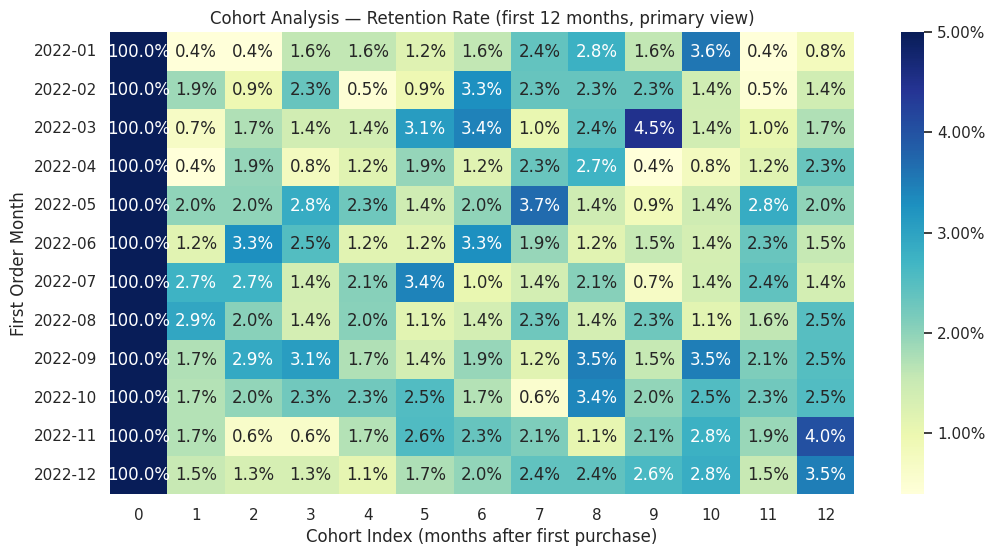

In [ ]:
cohort_size_monthly = df_cohort_table.iloc[:, 0]
retention_matrix_monthly = df_cohort_table.divide(cohort_size_monthly, axis=0)

MONTH_CUTOFF = 12  # primary analysis window — change here if needed
retention_focused = retention_matrix_monthly.loc[:, retention_matrix_monthly.columns <= MONTH_CUTOFF]

plt.figure(figsize=(12, 6))
ax = sns.heatmap(data=retention_focused, annot=True, cmap='YlGnBu', fmt='.1%', vmax=0.05, cbar=True)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xlabel('Cohort Index (months after first purchase)')
plt.ylabel('First Order Month')
plt.title(f'Cohort Analysis — Retention Rate (first {MONTH_CUTOFF} months, primary view)')
plt.show()

**Reading this chart:** column 0 is always 100% — that's each cohort's starting point. Everything after that shows what share of the original cohort came back in a given month. It's worth reading alongside cohort size (10b): a high retention percentage from a tiny remaining group means a lot less than the same percentage from a large one.

---

**What the M0–M12 heatmap shows**

Retention in Month 1 sits between just 0.4% and 2.9% across every cohort — over 97% of first-time buyers simply don't come back. From there through Month 12, the numbers stay flat in a 0.4%–4.5% range; there's no sudden "churn cliff," mostly because there was so little repeat activity to drop from in the first place. Even at the 12-month mark retention is still low (0.8%–4.0%), and there's no holiday bump — old customers aren't returning for seasonal sales, the business is simply acquiring new ones.

Given this, the highest-leverage move is probably an automated post-purchase journey (day 30–45) with skincare education and reorder incentives, timed to catch buyers before that early drop-off sets in.

### 10d. Key Retention Milestones (M1, M3, M6, M12)

Instead of analyzing every single month, we focus on four key milestones for business decision-making: **M1, M3, M6, and M12**.

* **Missing Data Handling:** If a newer cohort has not reached a certain milestone yet (e.g., a cohort from late 2023 at M12), it is marked as `NaN` or unreleased rather than guessed.

In [ ]:
milestones = [1, 3, 6, 12]
available_milestones = [m for m in milestones if m in retention_matrix_monthly.columns]
missing_milestones = [m for m in milestones if m not in retention_matrix_monthly.columns]

milestone_summary = retention_matrix_monthly[available_milestones].copy()
milestone_summary.columns = [f'M{m}' for m in available_milestones]

for m in missing_milestones:
    milestone_summary[f'M{m}'] = 'Not enough data'

milestone_summary = milestone_summary[[f'M{m}' for m in milestones]]
milestone_summary


,M1,M3,M6,M12
FirstMonth,,,,
2022-01,0.003968,0.015873,0.015873,0.007937
2022-02,0.018692,0.023364,0.032710,0.014019
2022-03,0.006897,0.013793,0.034483,0.017241
2022-04,0.003876,0.007752,0.011628,0.023256
2022-05,0.019886,0.028409,0.019886,0.019886
2022-06,0.011605,0.025145,0.032882,0.015474
2022-07,0.027397,0.013699,0.010274,0.013699
2022-08,0.029412,0.013575,0.013575,0.024887
2022-09,0.017375,0.030888,0.019305,0.025097


**Beyond M12:** if you need to comment on month 24 or 36, first check the
average remaining customers at that `month_after` from the 10b table above. If
it is a small handful, note explicitly that **"data is not large enough to draw
a conclusion"** rather than forcing a seasonal or lifecycle narrative onto a
number driven by 1-2 customers.

### 10e. Reading Seasonality: Calendar-Month View

The `month_after`-indexed heatmap above is deliberately *not* a revenue-by-
calendar-month view (see the note in Section 10 intro) — a seasonal spike
(e.g. every December) would appear as a **diagonal**, since December falls on
a different `month_after` for each cohort.

To make a seasonality check easier to read directly, we build an alternative
pivot indexed by the **actual calendar month** of the order instead of
`month_after`. If a promotion or seasonal effect exists, it will show up as a
**vertical bright column** shared across cohort rows — much easier to spot
than a diagonal.

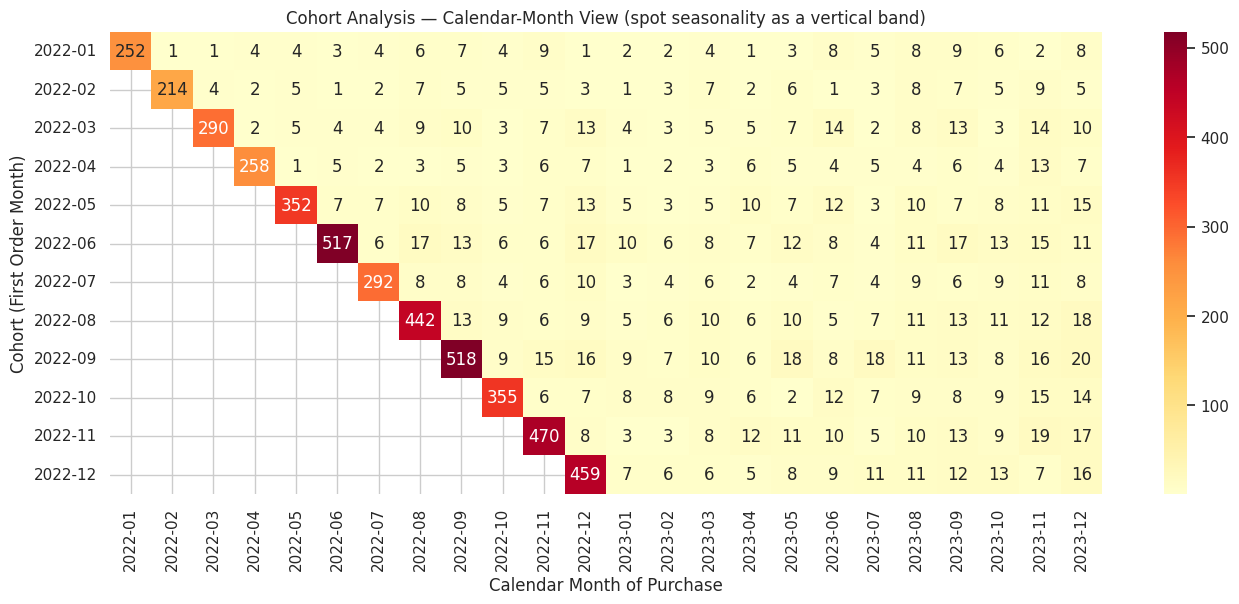

In [ ]:
df_pre_cohort['OrderMonth'] = df_pre_cohort['OrderDate'].dt.to_period('M')

calendar_view = df_pre_cohort[df_pre_cohort['FirstMonth'].dt.year == 2022].pivot_table(
    index='FirstMonth', columns='OrderMonth',
    values='CustomerID', aggfunc='nunique'
)

plt.figure(figsize=(16, 6))
sns.heatmap(data=calendar_view, annot=True, cmap='YlOrRd', fmt='g')
plt.xlabel('Calendar Month of Purchase')
plt.ylabel('Cohort (First Order Month)')
plt.title('Cohort Analysis — Calendar-Month View (spot seasonality as a vertical band)')
plt.show()


**What the calendar-month view shows**

Scanning down each column (say, `2022-12` or `2023-12`), the number of returning customers stays low — mostly single digits to around 15 per cohort — and no month stands out as a bright vertical band. The dark red cells all sit on the diagonal, which means those spikes are new customer sign-ups in that month, not old customers coming back for a seasonal sale.

Practically, this means CosmeticWorld's repeat orders aren't tied to holidays, so automated replenishment reminders (45–60 days after purchase) are likely to do more than holiday-timed campaigns.

**How to read this:** scan for a **column** (a specific calendar month) that
is consistently brighter across most cohort rows — that is a seasonality or
promotion effect shared by all cohorts, regardless of when each cohort
started. This directly corresponds to the "diagonal" pattern on the
`month_after`-indexed heatmap, just re-oriented to be easier to scan.

### 10f. Retention by Customer Segment: Consumer vs Corporate

We check whether **Consumer** and **Corporate** customers behave differently
after their first purchase, to see whether the retention strategy should
differ between B2C and B2B customers. We keep only `Consumer` and `Corporate`
since the third segment (`Self_Employed`) has too few customers for reliable
retention numbers. Consistent with 10c, the plot is capped at `month_after <= 15`.

In [ ]:
df_pre_cohort_seg = df_pre_cohort.merge(
    df_master[['CustomerID', 'Segment']].drop_duplicates(),
    on='CustomerID', how='inner'
)
df_pre_cohort_seg = df_pre_cohort_seg[df_pre_cohort_seg['Segment'].isin(['Consumer', 'Corporate'])]

cohort_segment = df_pre_cohort_seg.groupby(
    ['FirstMonth', 'Segment', 'month_after']
)['CustomerID'].nunique().reset_index()

segment_sizes = cohort_segment[cohort_segment['month_after'] == 0][
    ['FirstMonth', 'Segment', 'CustomerID']
].rename(columns={'CustomerID': 'CohortSize'})

df_segment_final = pd.merge(cohort_segment, segment_sizes, on=['FirstMonth', 'Segment'], how='left')
df_segment_final['RetentionRate'] = df_segment_final['CustomerID'] / df_segment_final['CohortSize']

df_segment_plot = df_segment_final[
    (df_segment_final['month_after'] > 0) & (df_segment_final['month_after'] <= MONTH_CUTOFF)
].sort_values(by='month_after')

df_segment_plot.head()


,FirstMonth,Segment,month_after,CustomerID,CohortSize,RetentionRate
2081,2023-11,Corporate,1,4,147,0.027211
2079,2023-11,Consumer,1,4,263,0.015209
2076,2023-10,Corporate,1,1,119,0.008403
2073,2023-10,Consumer,1,8,221,0.036199
2069,2023-09,Corporate,1,2,146,0.013699


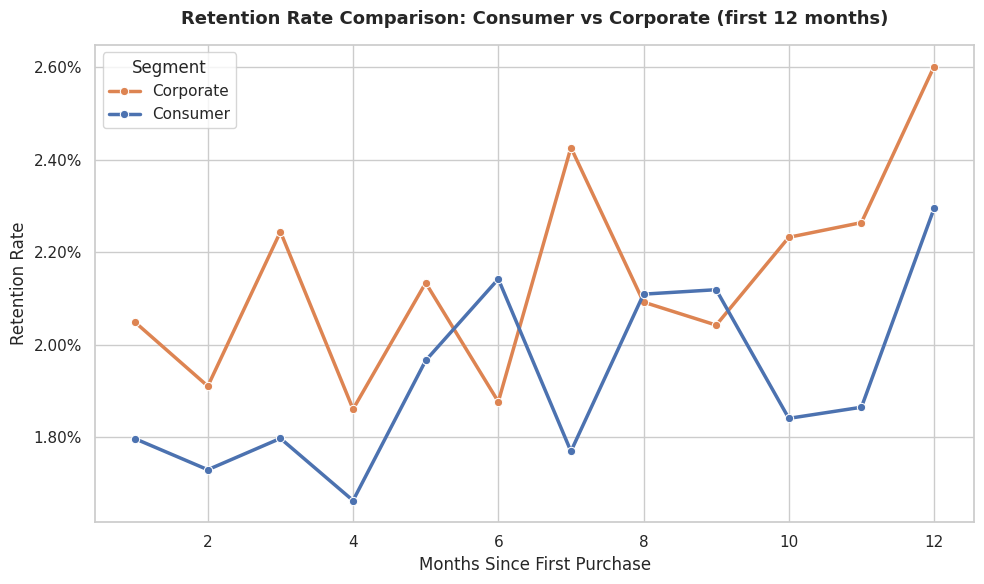

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_segment_plot,
    x='month_after', y='RetentionRate', hue='Segment',
    marker='o', linewidth=2.5,
    palette={'Consumer': '#4C72B0', 'Corporate': '#DD8452'},
    errorbar=None
)
plt.title(f'Retention Rate Comparison: Consumer vs Corporate (first {MONTH_CUTOFF} months)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Retention Rate')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
plt.legend(title='Segment')
plt.tight_layout()
plt.show()


In [ ]:
# Quantify the crossover instead of just eyeballing the chart
consumer_avg = df_segment_plot[df_segment_plot['Segment']=='Consumer']['RetentionRate'].mean()
corporate_avg = df_segment_plot[df_segment_plot['Segment']=='Corporate']['RetentionRate'].mean()
consumer_size = df_segment_final[(df_segment_final['Segment']=='Consumer') & (df_segment_final['month_after']==0)]['CustomerID'].sum()
corporate_size = df_segment_final[(df_segment_final['Segment']=='Corporate') & (df_segment_final['month_after']==0)]['CustomerID'].sum()

print(f"Consumer — avg retention M1-M12: {consumer_avg:.2%} | total cohort size: {consumer_size}")
print(f"Corporate — avg retention M1-M12: {corporate_avg:.2%} | total cohort size: {corporate_size}")

Consumer — avg retention M1-M12: 1.92% | total cohort size: 8987
Corporate — avg retention M1-M12: 2.14% | total cohort size: 5221


**Consumer vs. Corporate:** the two lines cross back and forth for all twelve months — neither one consistently comes out ahead. Corporate's average (2.14%) edges out Consumer's (1.92%), but that gap is small next to how much both lines swing month to month, and Corporate's cohort is roughly half the size of Consumer's (5,221 vs. 8,987), which alone would make it noisier. Nothing here suggests CosmeticWorld needs a separate retention strategy for B2B vs. B2C — one unified post-purchase journey should cover both.

### 10g. Retention by Annual Income Group

Finally, we test whether a customer's **income level** affects retention. We
split customers into 3 equal-sized tiers (`Low`, `Medium`, `High` Income) using
`pd.qcut`. Same `month_after <= 12` cap applied for consistency.

In [ ]:
df_pre_cohort_income = df_pre_cohort.merge(
    df_master[['CustomerID', 'AnnualIncome']].drop_duplicates(),
    on='CustomerID', how='inner'
)
df_pre_cohort_income['IncomeGroup'] = pd.qcut(
    df_pre_cohort_income['AnnualIncome'], q=3,
    labels=['Low Income', 'Medium Income', 'High Income']
)

cohort_income = df_pre_cohort_income.groupby(
    ['FirstMonth', 'IncomeGroup', 'month_after']
)['CustomerID'].nunique().reset_index()

income_sizes = cohort_income[cohort_income['month_after'] == 0][
    ['FirstMonth', 'IncomeGroup', 'CustomerID']
].rename(columns={'CustomerID': 'CohortSize'})

df_income_final = pd.merge(cohort_income, income_sizes, on=['FirstMonth', 'IncomeGroup'], how='left')
df_income_final['RetentionRate'] = df_income_final['CustomerID'] / df_income_final['CohortSize']

df_income_plot = df_income_final[
    (df_income_final['month_after'] > 0) & (df_income_final['month_after'] <= MONTH_CUTOFF)
].sort_values(by='month_after')

df_income_plot.head()


,FirstMonth,IncomeGroup,month_after,CustomerID,CohortSize,RetentionRate
3025,2021-10,Low Income,1,5,171,0.029240
5569,2023-03,High Income,1,0,69,0.000000
241,2020-02,High Income,1,0,50,0.000000
289,2020-03,Low Income,1,2,121,0.016529
2737,2021-08,Low Income,1,4,157,0.025478


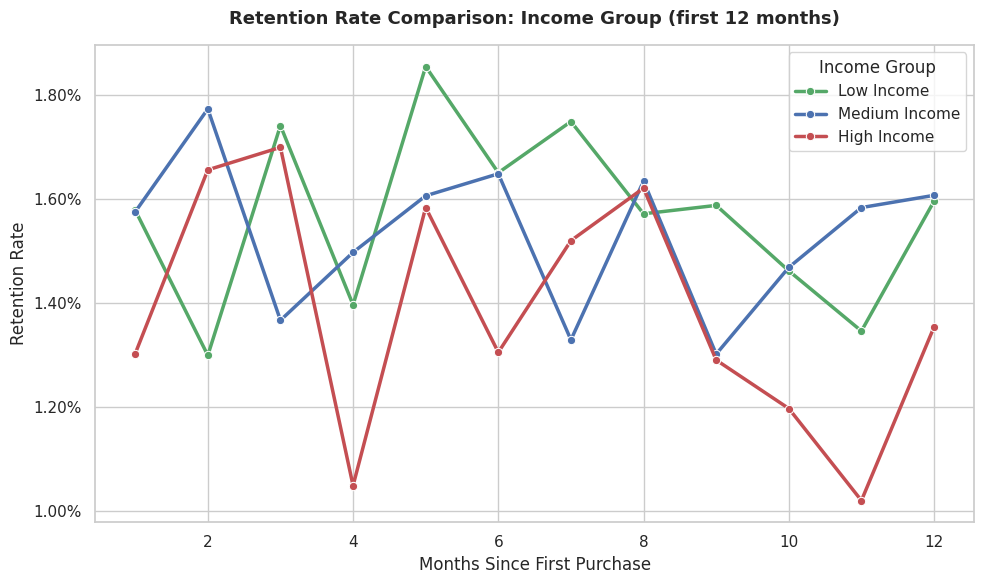

Average retention rate (M1-M12) by income group:
IncomeGroup
Low Income       0.0157
Medium Income    0.0153
High Income      0.0138
Name: RetentionRate, dtype: float64


In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_income_plot,
    x='month_after', y='RetentionRate', hue='IncomeGroup',
    marker='o', linewidth=2.5,
    palette={'Low Income': '#55A868', 'Medium Income': '#4C72B0', 'High Income': '#C44E52'},
    errorbar=None
)
plt.title(f'Retention Rate Comparison: Income Group (first {MONTH_CUTOFF} months)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Retention Rate')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
plt.legend(title='Income Group')
plt.tight_layout()
plt.show()

income_avg = df_income_plot.groupby('IncomeGroup')['RetentionRate'].mean().sort_values(ascending=False)
print("Average retention rate (M1-M12) by income group:")
print(income_avg.round(4))

**Retention by income group:** Low, Medium, and High Income customers move together in a fairly tight 1.0%–1.9% band, swapping places constantly — High Income leads at month 3, then falls to the bottom by month 11. There's no sign that income predicts loyalty here; the churn problem from Section 10c looks structural, not tied to how much a customer earns. That also means retention budget doesn't need to be tiered by income bracket.

### 10h. Cohort Retention Analysis: VIP Segments vs. Baseline Customers

To evaluate the long-term engagement and viability of potential candidates for the VIP gift-set initiative, this section examines the monthly retention trajectories of key customer segments over their first 12 months. Specifically, we compare the historical retention behavior of high-value segments (**Champions** and **Loyal**) against **All Other Segments** to assess whether VIP status translates into sustained purchasing activity over time.

> **Key Analytical Note:** `RFM_Segment` is computed from each customer's entire purchase history (including total frequency), so a customer is only labeled Champions or Loyal *because* they already made many repeat purchases. This means part of the retention gap shown below is expected by definition, not a new discovery — read this chart as a consistency check on the RFM labels, not as standalone proof that VIP treatment *causes* loyalty.

In [ ]:
# Attach each customer's final RFM segment to their cohort history.
# Note: RFM_Segment already reflects each customer's lifetime frequency,
# so grouping by it here is descriptive, not fully independent of the
# retention outcome we're about to measure (see caveat above).
df_pre_cohort_rfm = df_pre_cohort.merge(
    df_rfm[['CustomerID', 'RFM_Segment']],
    on='CustomerID',
    how='inner'
)

vip_segments = ['Champions', 'Loyal']
df_pre_cohort_rfm['SegmentGroup'] = df_pre_cohort_rfm['RFM_Segment'].apply(
    lambda x: x if x in vip_segments else 'All Other Segments'
)

In [ ]:
cohort_rfm = df_pre_cohort_rfm.groupby(
    ['FirstMonth', 'SegmentGroup', 'month_after']
)['CustomerID'].nunique().reset_index()

rfm_sizes = cohort_rfm[cohort_rfm['month_after'] == 0][
    ['FirstMonth', 'SegmentGroup', 'CustomerID']
].rename(columns={'CustomerID': 'CohortSize'})

In [ ]:
df_rfm_cohort_merged = pd.merge(cohort_rfm, rfm_sizes, on=['FirstMonth', 'SegmentGroup'], how='left')
df_rfm_cohort_merged.head()

,FirstMonth,SegmentGroup,month_after,CustomerID,CohortSize
0,2020-01,All Other Segments,0,198,198
1,2020-01,All Other Segments,3,3,198
2,2020-01,All Other Segments,4,1,198
3,2020-01,All Other Segments,5,4,198
4,2020-01,All Other Segments,7,5,198


In [ ]:
df_grouped = df_rfm_cohort_merged.groupby(['SegmentGroup', 'month_after'])[['CustomerID', 'CohortSize']].sum().reset_index()
df_grouped['RetentionRate'] = df_grouped['CustomerID'] / df_grouped['CohortSize']

df_rfm_cohort_plot = df_grouped[
    (df_grouped['month_after'] > 0) & (df_grouped['month_after'] <= MONTH_CUTOFF)
].sort_values(by='month_after')

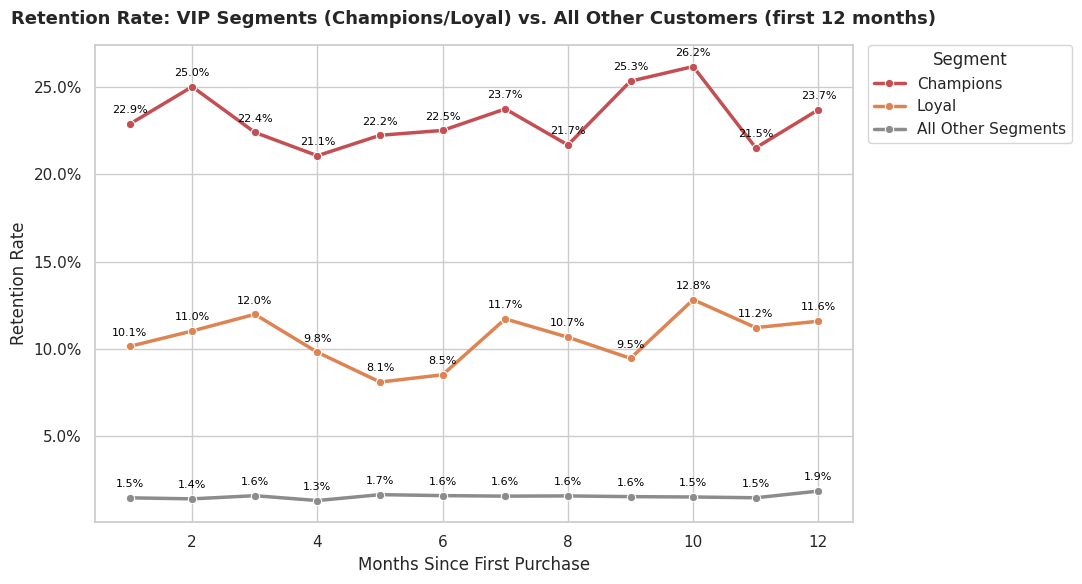

In [ ]:
plt.figure(figsize=(11, 6))

# Define palette and fix display order
palette_dict = {
    'Champions': '#C44E52',
    'Loyal': '#DD8452',
    'All Other Segments': '#8C8C8C'
}
hue_order = ['Champions', 'Loyal', 'All Other Segments']

# Plot retention rate trends
sns.lineplot(
    data=df_rfm_cohort_plot,
    x='month_after',
    y='RetentionRate',
    hue='SegmentGroup',
    hue_order=hue_order,
    palette=palette_dict,
    marker='o',
    linewidth=2.5,
    errorbar=None
)

plt.title(f'Retention Rate: VIP Segments (Champions/Loyal) vs. All Other Customers (first {MONTH_CUTOFF} months)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Retention Rate')

# Format Y-axis as percentage
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# Add numerical labels at each point
for segment_group in hue_order:
    segment_data = df_rfm_cohort_plot[df_rfm_cohort_plot['SegmentGroup'] == segment_group]
    for index, row in segment_data.iterrows():
        plt.text(row['month_after'], row['RetentionRate'] + 0.005,  # Increased offset for better visibility
                 f"{row['RetentionRate']:.1%}",
                 color='black', ha="center", va="bottom", fontsize=8) # Centered horizontally

# Position the legend outside the plot area (top right)
plt.legend(
    title='Segment',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=True
)

plt.tight_layout()
plt.show()

**VIP segments vs. baseline:** Champions retain at 21%-26%, Loyal at 8%-13%, versus under 2% for everyone else — a big gap, but one to read carefully. Since `RFM_Segment` is built from lifetime purchase frequency, customers only get labeled Champions or Loyal *because* they already kept buying — so this chart mostly confirms the RFM labels are internally consistent, rather than showing that VIP treatment itself creates loyalty. The underlying cohorts are also small (155 Champions, 473 Loyal), so the swings around Month 4–5 or Month 7 are more likely noise than a pattern worth timing a campaign around. For the actual VIP gift-set decision, Section 9's ABC × RFM cross-reference — which weighs profitability alongside current engagement — remains the stronger basis than this curve alone.

### Summary: Key Takeaways from Retention & Cohort Analysis

Bringing together the cohort, seasonality, and segment-level views from this section:

1. **CosmeticWorld's core challenge is acquisition-dependence, not seasonality.** Retention across all cohorts is extremely low and flat — M1 rates range from just 0.4% to 2.9%, with no sudden "churn cliff" and no holiday-driven spike (Section 10c, 10e). Over 97% of first-time buyers never return. Revenue growth today is driven almost entirely by acquiring new customers, not by repeat purchases.

2. **The retention problem is broad-based, not concentrated in one customer group.** Neither business segment (Consumer vs. Corporate, Section 10f) nor income level (Section 10g) shows a systematic, reliable difference in retention behavior. This rules out a natural hypothesis a stakeholder might raise — "should retention spend be prioritized by segment or income tier?" — the data says no. The low-retention pattern is structural to the business, not isolated to a specific customer profile.

3. **Strategic implication:** because the problem is broad and not segment-specific, the highest-leverage fix is a **single, unified retention mechanism** applied across the customer base — for example, an automated post-purchase journey (Day 30–45) with skincare education and re-order incentives — rather than building multiple segment-specific campaigns. This keeps the recommendation actionable within CosmeticWorld's stated budget constraints (Section 6) and complements the VIP gift-set strategy from Section 9, which targets high-value customers who are *already* engaged rather than trying to solve retention for the broader base.

4. **VIP segments show the expected internal consistency (Section 10h).** Champions and Loyal customers retain at much higher rates than the rest of the base — unsurprising, since these labels are partly defined by repeat-purchase history. This does not change the broad-based retention problem described above, but it does support treating the VIP gift-set (Section 9) as a loyalty-reinforcement tool for an already-engaged core, rather than as a fix for the wider retention gap.